# Lumen Book Recommender System — Data & Model Analysis

This notebook explores the Book-Crossing dataset and demonstrates the three recommendation models used by the Lumen application: **Collaborative Filtering**, **Content-Based Filtering**, and **Hybrid Filtering**.

The notebook imports the same cleaned catalogue and rating data used by the Flask application so the reported dataset counts and model inputs stay consistent with the website.

The visualisations are selected according to the type of data being analysed: counts use bar charts, distributions use bars, relationships use scatter plots, and recommendation results are shown as ranked tables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collaborative_filtering import build_collaborative_model, get_collaborative_recommendations
from content_based_filtering import build_content_model, get_content_recommendations
from hybrid_filtering import get_hybrid_recommendations
from data_service import (
    load_catalogue,
    load_all_ratings,
    load_explicit_ratings,
    load_users,
    display_books as load_display_books,
    content_candidate_catalogue,
)

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')


## 1. Load and clean the dataset

In [2]:
# Reuse the application's preprocessing instead of maintaining a second
# notebook-only cleaning pipeline.
books = load_catalogue().copy()
ratings = load_all_ratings().copy()
explicit = load_explicit_ratings().copy()
users = load_users().copy()
display_books = load_display_books().copy()

summary = pd.DataFrame({
    'Dataset': ['Books (raw catalogue rows)', 'All rating events', 'Explicit ratings', 'Users', 'Unique title-author books'],
    'Records': [len(books), len(ratings), len(explicit), len(users), len(display_books)]
})
summary


,Dataset,Records
0,Books (raw catalogue rows),271360
1,All rating events,1149780
2,Explicit ratings,433671
3,Users,278858
4,Unique title-author books,245282


In [3]:
books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']].head(10)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for th...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company
5,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group
6,0425176428,What If?: The World's Foremost Military Historians Imagine What Might Have Been,Robert Cowley,2000,Berkley Publishing Group
7,0671870432,PLEADING GUILTY,Scott Turow,1993,Audioworks
8,0679425608,Under the Black Flag: The Romance and the Reality of Life Among the Pirates,David Cordingly,1996,Random House
9,074322678X,Where You'll Find Me: And Other Stories,Ann Beattie,2002,Scribner


## 2. Implicit vs explicit rating activity
A rating of **0** in this dataset represents implicit interaction, while ratings **1–10** are explicit scores.

The reader-facing Flask interface preserves and displays these ten explicit levels directly on the **1–10** scale. Personal ratings use the same 1–10 integer scale, keeping the dataset, interface and recommendation profile consistent.


In [4]:
rating_type = pd.DataFrame({
    'Type': ['Implicit interaction (0)', 'Explicit rating (1–10)'],
    'Count': [(ratings['Book-Rating'] == 0).sum(), (ratings['Book-Rating'] > 0).sum()]
})
rating_type

,Type,Count
0,Implicit interaction (0),716109
1,Explicit rating (1–10),433671


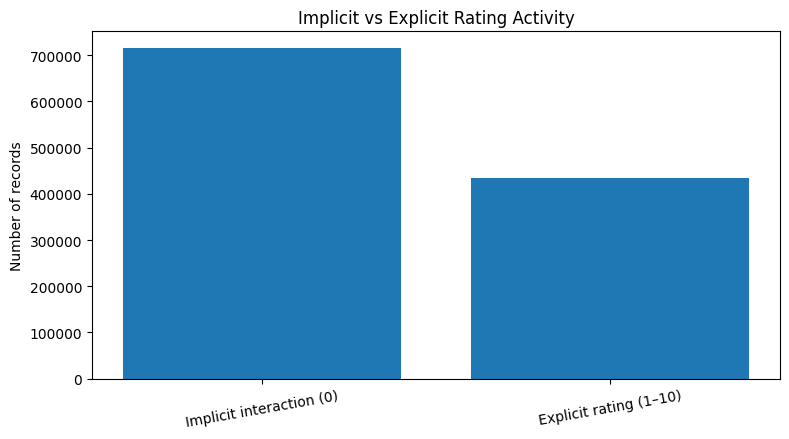

In [5]:
plt.figure(figsize=(8, 4.5))
plt.bar(rating_type['Type'], rating_type['Count'])
plt.title('Implicit vs Explicit Rating Activity')
plt.ylabel('Number of records')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 3. Distribution of explicit ratings
A bar chart is appropriate because ratings are discrete categories from 1 to 10.

The notebook and the reader-facing interface both keep the original **1–10** values, so the technical analysis, displayed scores and personal ratings use one consistent scale.


In [6]:
explicit_distribution = explicit['Book-Rating'].value_counts().sort_index()
explicit_distribution


Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

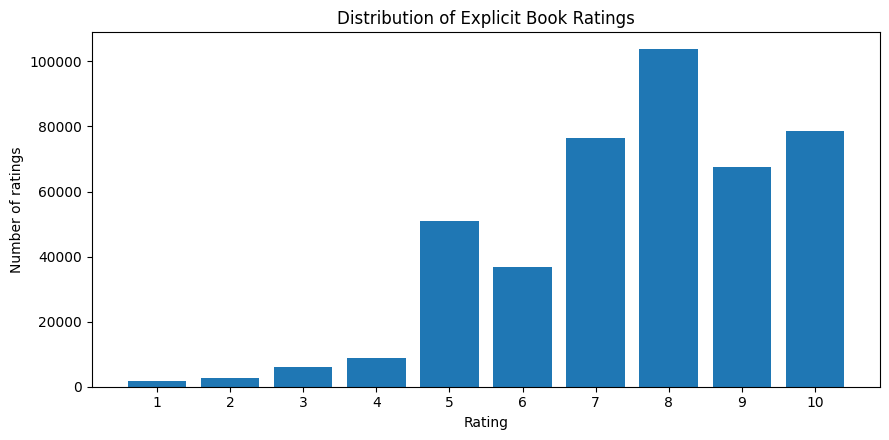

In [7]:
plt.figure(figsize=(9, 4.5))
plt.bar(explicit_distribution.index.astype(int), explicit_distribution.values)
plt.title('Distribution of Explicit Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of ratings')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 4. Book-level rating statistics

In [8]:
rating_with_books = explicit.merge(
    books[['ISBN', 'Book-Title', 'Book-Author', 'Book-Key']], on='ISBN', how='inner'
)
book_stats = (
    rating_with_books.groupby(['Book-Key', 'Book-Title', 'Book-Author'])
    .agg(num_ratings=('Book-Rating', 'count'), avg_rating=('Book-Rating', 'mean'))
    .reset_index()
)
book_stats.describe()[['num_ratings', 'avg_rating']]

,num_ratings,avg_rating
count,139642.0000,139642.0000
mean,2.7488,7.5219
std,8.7871,1.7107
min,1.0000,1.0000
25%,1.0000,6.5000
50%,1.0000,8.0000
75%,2.0000,9.0000
max,707.0000,10.0000


### Most frequently rated books
A horizontal bar chart makes long book titles easier to read.

In [9]:
most_rated = book_stats.sort_values('num_ratings', ascending=False).head(15)
most_rated[['Book-Title', 'Book-Author', 'num_ratings', 'avg_rating']]

,Book-Title,Book-Author,num_ratings,avg_rating
113966,The Lovely Bones: A Novel,Alice Sebold,707,8.1853
136346,Wild Animus,Rich Shapero,581,4.3907
106109,The Da Vinci Code,Dan Brown,488,8.4385
120469,The Secret Life of Bees,Sue Monk Kidd,406,8.4778
115812,The Nanny Diaries: A Novel,Emma McLaughlin,393,7.4377
119101,The Red Tent (Bestselling Backlist),Anita Diamant,383,8.1828
16185,Bridget Jones's Diary,Helen Fielding,377,7.6260
62299,Life of Pi,Yann Martel,336,8.0804
46539,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,326,8.8405
30713,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,323,7.8762


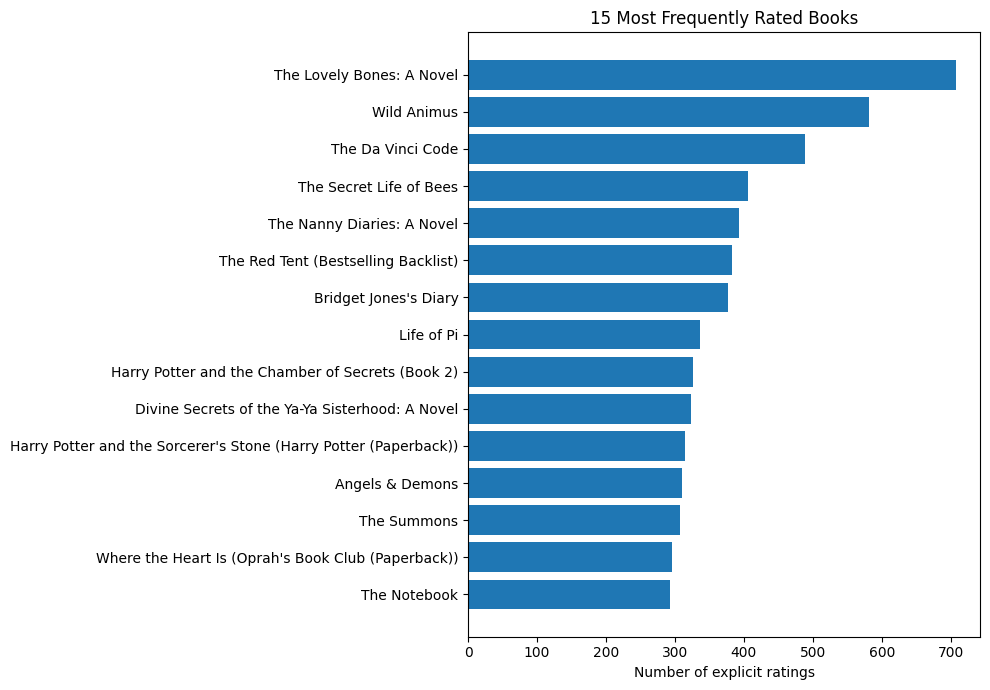

In [10]:
plot_data = most_rated.sort_values('num_ratings')
plt.figure(figsize=(10, 7))
plt.barh(plot_data['Book-Title'], plot_data['num_ratings'])
plt.title('15 Most Frequently Rated Books')
plt.xlabel('Number of explicit ratings')
plt.tight_layout()
plt.show()

### Highest-rated books with enough evidence
To avoid ranking a book highly because of only one or two ratings, this view requires at least **100 explicit ratings**.

In [11]:
high_confidence = (
    book_stats[book_stats['num_ratings'] >= 100]
    .sort_values(['avg_rating', 'num_ratings'], ascending=[False, False])
    .head(15)
)
high_confidence[['Book-Title', 'Book-Author', 'num_ratings', 'avg_rating']]

,Book-Title,Book-Author,num_ratings,avg_rating
46545,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,247,9.1255
46566,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,176,9.0625
46551,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling,211,9.0474
46557,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,277,9.0433
127644,To Kill a Mockingbird,Harper Lee,267,8.9775
46567,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling,315,8.9365
35342,Ender's Game (Ender Wiggins Saga (Paperback)),Orson Scott Card,151,8.9205
46539,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,326,8.8405
108327,"The Fellowship of the Ring (The Lord of the Rings, Part 1)",J.R.R. TOLKIEN,131,8.8397
386,1984,George Orwell,144,8.7847


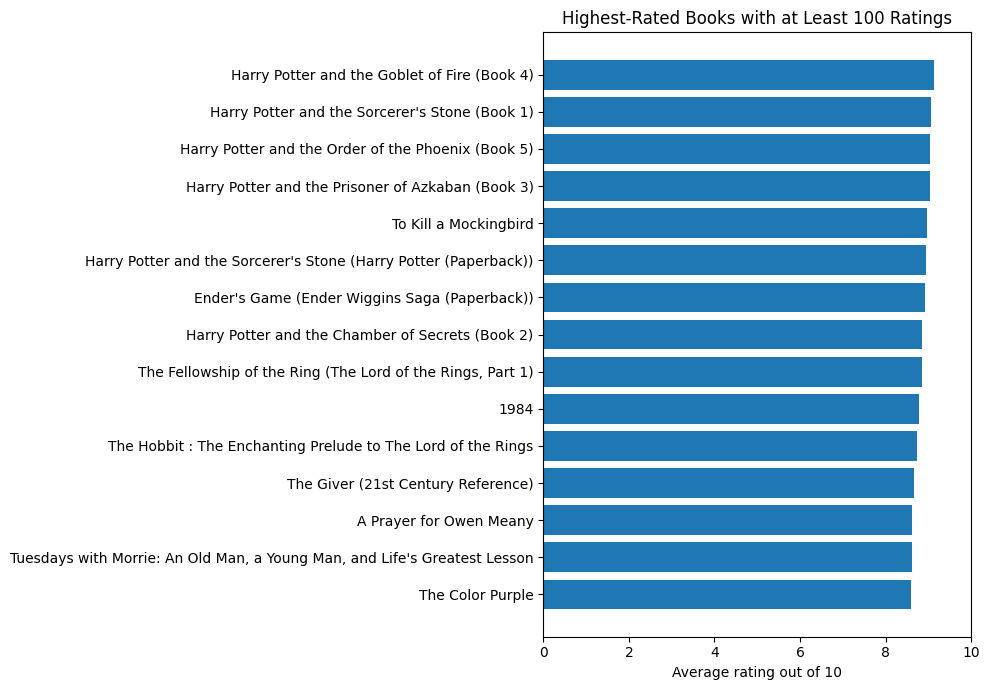

In [12]:
plot_data = high_confidence.sort_values('avg_rating')
plt.figure(figsize=(10, 7))
plt.barh(plot_data['Book-Title'], plot_data['avg_rating'])
plt.title('Highest-Rated Books with at Least 100 Ratings')
plt.xlabel('Average rating out of 10')
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

## 5. Publication trend
Publication years are grouped by decade to reduce noise and show the catalogue's overall time distribution.

In [13]:
valid_years = pd.to_numeric(books['year_numeric'], errors='coerce').dropna()
decades = ((valid_years // 10) * 10).astype(int).value_counts().sort_index()
decades_df = decades.rename_axis('Decade').reset_index(name='Books')
decades_df


,Decade,Books
0,1900,17
1,1910,23
2,1920,65
3,1930,57
4,1940,127
5,1950,623
6,1960,1773
7,1970,12769
8,1980,52778
9,1990,126016


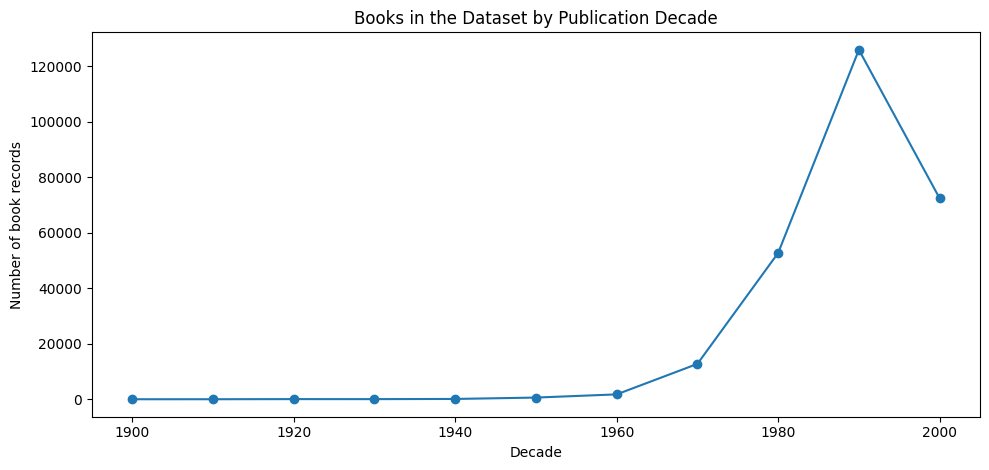

In [14]:
plt.figure(figsize=(10, 4.8))
plt.plot(decades_df['Decade'], decades_df['Books'], marker='o')
plt.title('Books in the Dataset by Publication Decade')
plt.xlabel('Decade')
plt.ylabel('Number of book records')
plt.tight_layout()
plt.show()

## 6. Rating volume vs average rating
A scatter plot is suitable because both variables are numeric. The x-axis is logarithmic because rating counts are highly skewed.

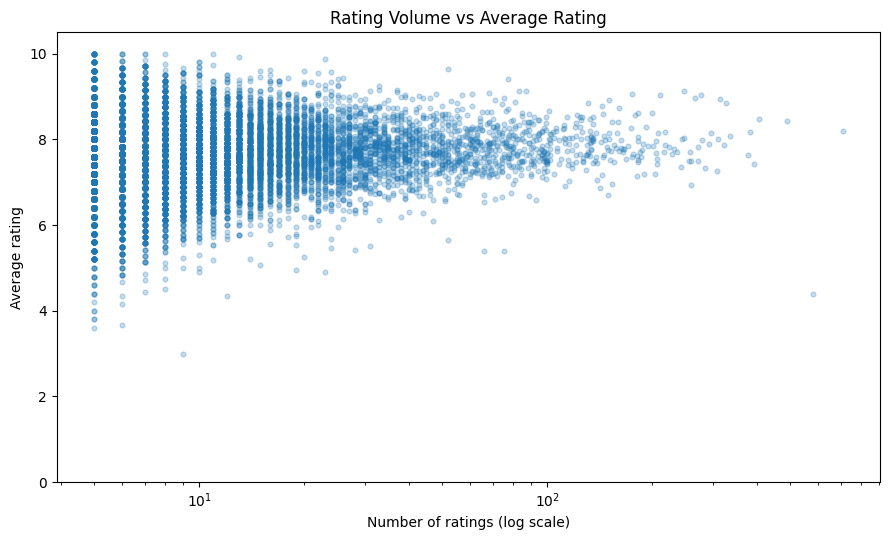

In [15]:
scatter_data = book_stats[book_stats['num_ratings'] >= 5].copy()
plt.figure(figsize=(9, 5.5))
plt.scatter(scatter_data['num_ratings'], scatter_data['avg_rating'], alpha=0.25, s=12)
plt.xscale('log')
plt.title('Rating Volume vs Average Rating')
plt.xlabel('Number of ratings (log scale)')
plt.ylabel('Average rating')
plt.ylim(0, 10.5)
plt.tight_layout()
plt.show()

## 7. Build the recommendation models

In [16]:
book_user_matrix, collaborative_sparse_matrix = build_collaborative_model(
    books_data=books,
    ratings_data=explicit,
    minimum_user_ratings=20,
    minimum_book_ratings=10
)

# Use exactly the same content candidate catalogue as the live Flask app.
content_candidates = content_candidate_catalogue().copy()
content_index, content_vectorizer, content_matrix, content_key_to_position = build_content_model(
    content_candidates,
    max_features=40000
)

print('Collaborative matrix:', book_user_matrix.shape)
print('Content candidate matrix:', content_matrix.shape)


Collaborative matrix: (2768, 3192)
Content candidate matrix: (47350, 40000)


## 8. Choose one seed book
The notebook uses **The Da Vinci Code** when available. If it is not found, it falls back to the most frequently rated book.

In [17]:
preferred = display_books[display_books['Book-Title'].str.casefold().eq('the da vinci code')]
if not preferred.empty:
    selected_book_key = preferred.iloc[0]['Book-Key']
else:
    selected_book_key = most_rated.iloc[0]['Book-Key']

selected_book = display_books[display_books['Book-Key'] == selected_book_key].iloc[0]
selected_book[['Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication']]

Book-Title             The Da Vinci Code
Book-Author                    Dan Brown
Publisher                      Doubleday
Year-Of-Publication                 2003
Name: 738, dtype: object

## 9. Collaborative Filtering recommendations

In [18]:
collaborative_recs = get_collaborative_recommendations(
    selected_book_key=selected_book_key,
    book_user_matrix=book_user_matrix,
    sparse_matrix=collaborative_sparse_matrix,
    display_book_data=display_books,
    number_of_recommendations=15
)
collaborative_recs[['Book-Title', 'Book-Author', 'collaborative_score']].head(10)

,Book-Title,Book-Author,collaborative_score
0,Angels & Demons,Dan Brown,0.2603
1,Middlesex: A Novel,Jeffrey Eugenides,0.1895
2,Digital Fortress : A Thriller,Dan Brown,0.1715
3,The Lovely Bones: A Novel,Alice Sebold,0.1699
4,The Secret Life of Bees,Sue Monk Kidd,0.1660
5,The Twentieth Wife: A Novel,Indu Sundaresan,0.1452
6,The Sweet Potato Queens' Book of Love,JILL CONNER BROWNE,0.1387
7,Timeline,MICHAEL CRICHTON,0.1365
8,Street Dreams,Faye Kellerman,0.1364
9,Deception Point,Dan Brown,0.1358


## 10. Content-Based Filtering recommendations

In [19]:
content_recs = get_content_recommendations(
    selected_book_key=selected_book_key,
    content_index=content_index,
    content_matrix=content_matrix,
    key_to_position=content_key_to_position,
    number_of_recommendations=15,
    vectorizer=content_vectorizer,
    selected_book_row=selected_book
)
content_recs[['Book-Title', 'Book-Author', 'content_score', 'recommendation_reason']].head(10)

,Book-Title,Book-Author,content_score,recommendation_reason
177,Deception Point,Dan Brown,0.5693,"Same author, similar publication period"
6921,Illuminati.,Dan Brown,0.5641,"Same author, similar publication period"
89,Angels & Demons,Dan Brown,0.5287,"Same author, similar publication period"
272,Digital Fortress : A Thriller,Dan Brown,0.5195,"Same author, similar publication period"
6543,Secrets of the Code: The Unauthorized Guide to the Mysteries Behind The Da V...,Dan Burstein,0.3568,Similar publication period
35692,Bringing Elizabeth Home : A Journey of Faith and Hope,ED SMART,0.3491,"Same publisher, similar publication period"
28207,"Cracking Da Vinci's Code: You've Read the Fiction, Now Read the Facts",James Garlow,0.3356,Similar publication period
41006,Palladio : A Novel,JONATHAN DEE,0.3304,"Same publisher, similar publication period"
163,Bleachers,John Grisham,0.3017,"Same publisher, similar publication period"
19992,Q: The Autobiography of Quincy Jones,QUINCY JONES,0.2918,"Same publisher, similar publication period"


## 11. Hybrid Filtering recommendations
The default blend uses **55% collaborative signal + 45% content signal**. Collaborative evidence receives a slightly higher weight because reader-behaviour patterns provide direct preference evidence, while content similarity supports sparse and cold-start books.

The **55/45 blend is a prototype design choice, not a claim that this weight is globally optimal**. Tuning weights should use a separate validation set rather than the held-out test readers. If collaborative data is unavailable for a book, the implementation automatically falls back to content-based results.


In [20]:
hybrid_recs = get_hybrid_recommendations(
    collaborative_results=collaborative_recs,
    content_results=content_recs,
    rating_statistics=book_stats[['Book-Key', 'num_ratings', 'avg_rating']],
    collaborative_weight=0.55,
    number_of_recommendations=15
)
hybrid_recs[['Book-Title', 'Book-Author', 'hybrid_score', 'collaborative_score', 'content_score', 'recommendation_reason']].head(10)


,Book-Title,Book-Author,hybrid_score,collaborative_score,content_score,recommendation_reason
0,Angels & Demons,Dan Brown,0.9679,0.2603,0.5287,Strong reader-behaviour and content match
1,Digital Fortress : A Thriller,Dan Brown,0.7731,0.1715,0.5195,Strong reader-behaviour and content match
2,Deception Point,Dan Brown,0.7370,0.1358,0.5693,Strong reader-behaviour and content match
3,Illuminati.,Dan Brown,0.4459,0.0000,0.5641,"Same author, similar publication period"
4,Middlesex: A Novel,Jeffrey Eugenides,0.4003,0.1895,0.0000,Readers with similar tastes also liked this
5,The Lovely Bones: A Novel,Alice Sebold,0.3590,0.1699,0.0000,Readers with similar tastes also liked this
6,The Secret Life of Bees,Sue Monk Kidd,0.3508,0.1660,0.0000,Readers with similar tastes also liked this
7,The Twentieth Wife: A Novel,Indu Sundaresan,0.3068,0.1452,0.0000,Readers with similar tastes also liked this
8,The Sweet Potato Queens' Book of Love,JILL CONNER BROWNE,0.2931,0.1387,0.0000,Readers with similar tastes also liked this
9,Timeline,MICHAEL CRICHTON,0.2885,0.1365,0.0000,Readers with similar tastes also liked this


## 12. Hybrid score contribution
This stacked horizontal chart shows how much each signal contributes to the final ranking for the top recommendations.

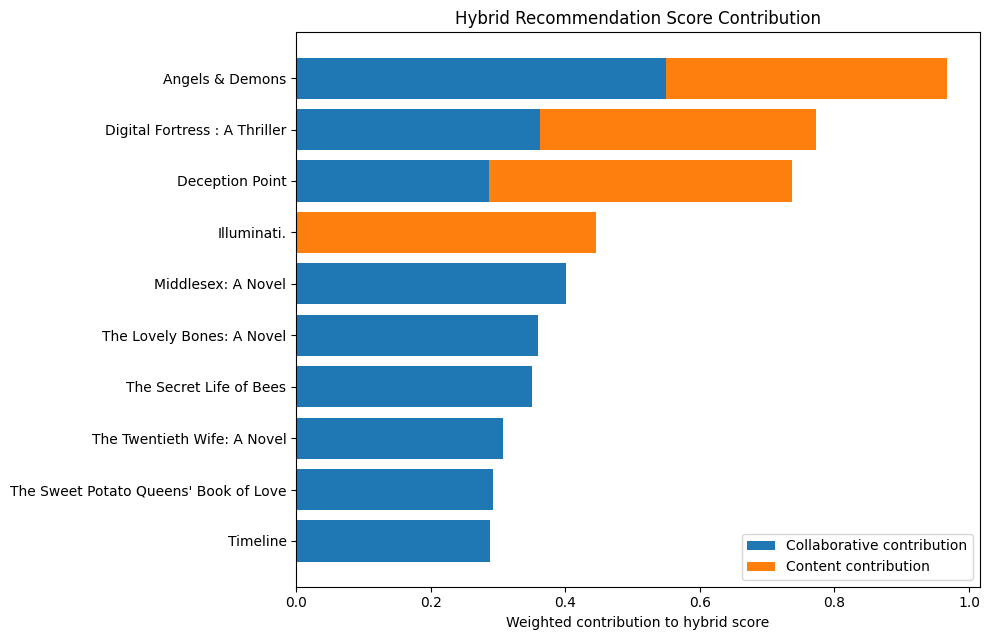

In [21]:
top_hybrid = hybrid_recs.head(10).copy()
if 'collaborative_component' in top_hybrid and 'content_component' in top_hybrid:
    top_hybrid['Collaborative contribution'] = 0.55 * top_hybrid['collaborative_component']
    top_hybrid['Content contribution'] = 0.45 * top_hybrid['content_component']
else:
    top_hybrid['Collaborative contribution'] = 0
    top_hybrid['Content contribution'] = top_hybrid['hybrid_score']

plot_data = top_hybrid.iloc[::-1]
plt.figure(figsize=(10, 6.5))
plt.barh(plot_data['Book-Title'], plot_data['Collaborative contribution'], label='Collaborative contribution')
plt.barh(
    plot_data['Book-Title'],
    plot_data['Content contribution'],
    left=plot_data['Collaborative contribution'],
    label='Content contribution'
)
plt.title('Hybrid Recommendation Score Contribution')
plt.xlabel('Weighted contribution to hybrid score')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Interpretation

- **Collaborative Filtering** is strongest when the selected book has enough reader-rating history.
- **Content-Based Filtering** can recommend even when collaborative history is sparse because it uses book metadata.
- **Hybrid Filtering** combines both signals to improve coverage and balance behavioural similarity with book characteristics.
- Popularity is used only as a tie-breaker in the hybrid ranking; it does not replace the two core recommendation signals.

## 14. Offline recommendation evaluation

The project includes a reproducible **held-out-user evaluation** using up to **50 eligible readers**. Active readers with several books rated **8/10 or above** are sampled, and **all ratings from those evaluation readers are removed before the collaborative model and training-derived popularity statistics are built**.

For each held-out reader, one known positive book is used only as the recommendation seed. The reader's other highly rated books form the unseen relevance set. The three approaches are compared with **Precision@10, Recall@10, F1@10, Hit Rate@10, Recommendation Availability, Catalog Coverage@10, and mean recommendation time**.

This protocol avoids direct leakage from the evaluated readers' ratings into collaborative model construction. It is still an offline proxy because historical high ratings are treated as relevance labels rather than live user-acceptance data.


In [22]:
evaluation_results = pd.read_csv('recommender_evaluation_results.csv')
evaluation_results

,Model,Precision@10,Recall@10,F1@10,Hit Rate@10,Recommendation Availability,Catalog Coverage@10,Unique Recommended Books,Recommendable Catalog Size,Mean Recommendation Time (ms),Test Cases
0,Collaborative Filtering,0.0500,0.0167,0.0240,0.2000,0.9600,0.0958,261,2724,80.3479,50
1,Hybrid Filtering,0.0480,0.0156,0.0224,0.2200,1.0000,0.0061,285,46886,181.8799,50
2,Content-Based Filtering,0.0380,0.0122,0.0179,0.1400,1.0000,0.0066,310,46886,42.8814,50


### Accuracy comparison
A grouped bar chart is appropriate here because the metrics are comparable proportions for three discrete recommendation approaches.

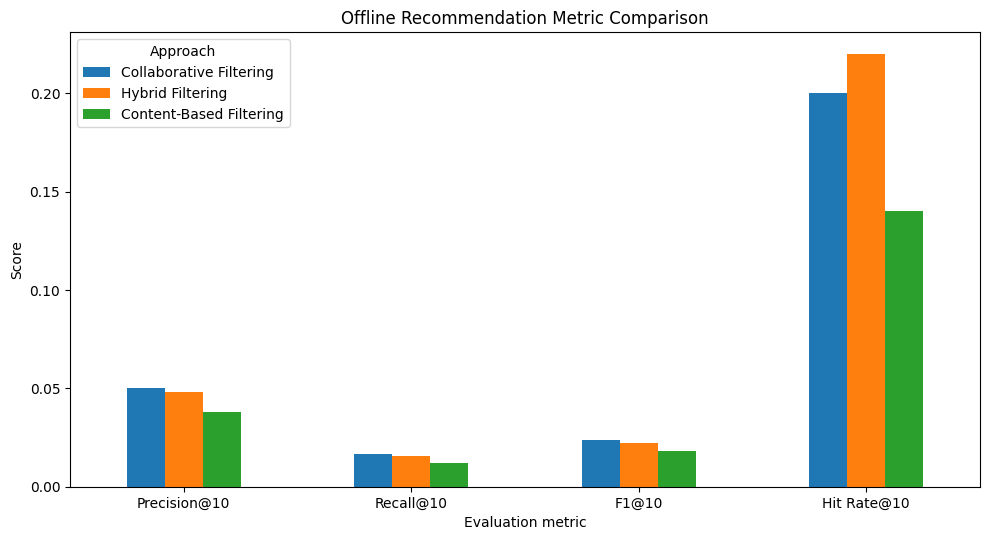

In [23]:
metric_columns = ['Precision@10', 'Recall@10', 'F1@10', 'Hit Rate@10']
plot_eval = evaluation_results.set_index('Model')[metric_columns].T

plt.figure(figsize=(10, 5.5))
plot_eval.plot(kind='bar', ax=plt.gca())
plt.title('Offline Recommendation Metric Comparison')
plt.ylabel('Score')
plt.xlabel('Evaluation metric')
plt.xticks(rotation=0)
plt.legend(title='Approach')
plt.tight_layout()
plt.show()

### Efficiency comparison
Lower recommendation time is better. The hybrid approach is expected to take longer because it computes both behavioural and content candidates before combining them.

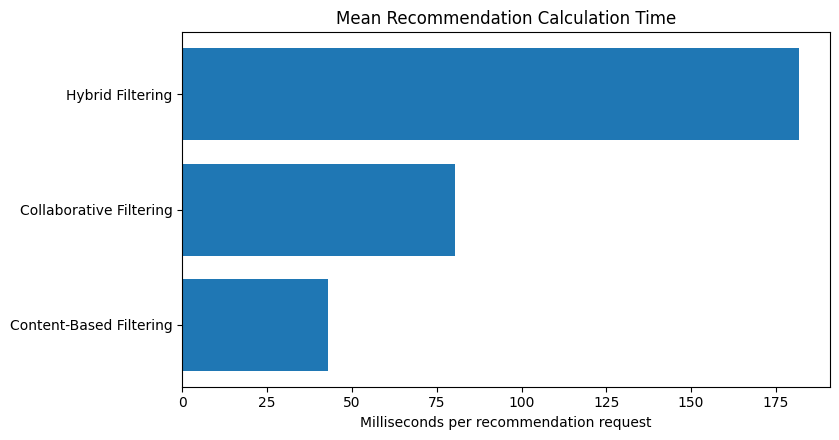

,Model,Mean Recommendation Time (ms),Recommendation Availability,Catalog Coverage@10,Unique Recommended Books,Recommendable Catalog Size
2,Content-Based Filtering,42.8814,1.0000,0.0066,310,46886
0,Collaborative Filtering,80.3479,0.9600,0.0958,261,2724
1,Hybrid Filtering,181.8799,1.0000,0.0061,285,46886


In [24]:
efficiency = evaluation_results.sort_values('Mean Recommendation Time (ms)')
plt.figure(figsize=(8.5, 4.5))
plt.barh(efficiency['Model'], efficiency['Mean Recommendation Time (ms)'])
plt.title('Mean Recommendation Calculation Time')
plt.xlabel('Milliseconds per recommendation request')
plt.tight_layout()
plt.show()

efficiency[[
    'Model',
    'Mean Recommendation Time (ms)',
    'Recommendation Availability',
    'Catalog Coverage@10',
    'Unique Recommended Books',
    'Recommendable Catalog Size'
]]


## 15. Evaluation discussion

- **F1@10** balances precision and recall and is useful for comparing the three approaches under the same held-out-user protocol.
- In the included **50-reader** run, **Collaborative Filtering has the highest Precision@10, Recall@10 and F1@10**, while **Hybrid Filtering has the highest Hit Rate@10 and 100% recommendation availability**. The result shows that no single approach wins every metric.
- **Recommendation Availability** measures the proportion of evaluation cases in which the model successfully returned at least one recommendation. It is not the same as catalogue coverage.
- **Catalog Coverage@10** is calculated as the number of unique books surfaced across Top-10 test lists divided by that model's recommendable catalogue size.
- The hybrid approach combines behavioural and metadata evidence. It may require more computation because both candidate lists are generated before fusion.
- Low absolute Precision/Recall values are reasonable in a catalogue with tens of thousands of recommendable books because each held-out reader has only a small known relevance set.
- The held-out-user design is stronger than an in-sample check, but a future study could still add temporal splits, more evaluation users, weight tuning on a separate validation set, and a user-satisfaction questionnaire.
